**Finding a local minimum of a multivariate function**
Our interest today will be finding a (local) minimum of a multivariate function $f \colon U \to \mathbf{R}$, where $U \subseteq \mathbb{R}^n$. (Of course, we already know how to do that with appropriate use of Newton's iteration.) The _gradient descent method_ (tries to) find a minimum of a function $f \colon U \to \mathbb{R}$ by starting with some initial guess $\mathbf{x}^{(0)}$, and then continue iteratively:
\begin{align*}
	\mathbf{x}^{(1)} &= \mathbf{x}^{(0)} - \alpha \mathop{grad} f (\mathbf{x}^{(0)}) \textrm{, } \\
	\mathbf{x}^{(2)} &= \mathbf{x}^{(1)} - \alpha \mathop{grad} f (\mathbf{x}^{(1)}) \textrm{, } \\
			    &\ \; \vdots \\
	\mathbf{x}^{(k+1)} &= \mathbf{x}^{(k)} - \alpha \mathop{grad} f (\mathbf{x}^{(k)}) \textrm{. }
\end{align*}
Here, the step size $\alpha > 0$ is a carefully chosen (small) real number. (The convergence of such method depends on $f$, initial guess $\mathbf{x}^{(0)}$, and the choice of $\alpha$.) 

**Task 1** A function $f$ is given by $$f(x,y) = (1-x)^2 + 4(y-x^2)^2 \textrm{. }$$

- Find the minimum of $f$.
- Find (an approximation for) the minimum of the function $f$ using the gradient descent method. Write a _Julia_ function `gradmet(gradf, alpha, x0, tol, maxit)`, which runs this method for the function `f` with gradient `gradf`, step size `alpha`, and initial guess `x0`. (We use `maxit` to limit the maximum allowed number of iterations, and `tol` to prescribe desired accuracy.)
- Modify the function `gradmet` to optionally return the steps of the gradient descent iteration and plot those steps for some examples.

In [38]:
using LinearAlgebra
function gradmet(gradf, alpha, x0; tol = 1e-6, maxit = 10000, record_steps = false)
    n = 1
    x = x0
    steps = [Float64.(x0)]
    for outer n in 1:maxit
        # one step of gradient descent
        x = x0 - alpha*gradf(x0)
        # optionally add x to steps
        #
        # YOUR CODE HERE
        if record_steps
           push!(steps, x) 
        end
        # check if new x is within tolerance and ...
        if norm(x-x0) < alpha*tol
            break
        end
        # ... repeat if it is not
        x0 = x
    end

    # a warning if maxit was reached
    if n == maxit
        @warn "no convergence after $maxit iterations"
    end
    # let's return a named tuple
    if record_steps
        return (X = x, n = n, steps = steps)
    else
        return (X = x, n = n)
    end
end

gradmet (generic function with 1 method)

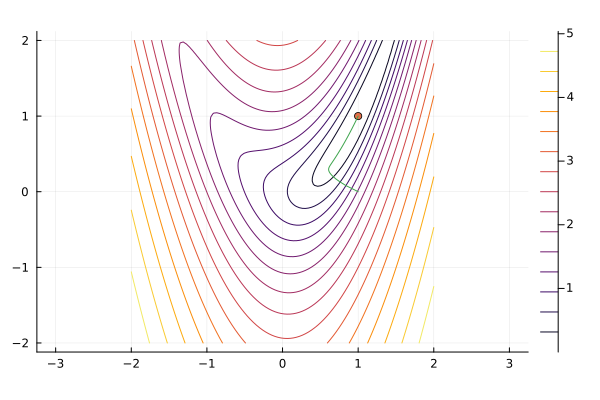

In [56]:
#lets plot the contours of f
using Plots
xr = LinRange(-2, 2, 100)
yr = LinRange(-2, 2, 100)
z = [log(f([x; y])+1) for y in yr, x in xr]
contour(xr, yr, z, ratio = 1)
scatter!((1, 1), label = false)
plot!([Tuple(T) for T in koraki]; label = false)

In [55]:
using Plots
f(X) = (1-X[1])^2 + 4*(X[2]-X[1]^2)^2
gradf(X) = [-2*(1-X[1]) - 16*(X[2]-X[1]^2)*X[1]; 8*(X[2]-X[1]^2)]
koraki = gradmet(gradf, 0.01, [1; 0]; tol = 1e-10, record_steps=true).steps


5583-element Vector{Vector{Float64}}:
 [1.0, 0.0]
 [0.84, 0.08]
 [0.75911936, 0.130048]
 [0.7097401984004983, 0.16574513621814477]
 [0.67716423284393, 0.19278401725873948]
 [0.6548260418415761, 0.21404540773748898]
 [0.6392295161825674, 0.23122554672440232]
 [0.628302177944507, 0.24541665293517007]
 [0.6207225297528396, 0.25736441084514133]
 [0.6156024304327238, 0.2675989746929512]
 [0.6123210972865529, 0.2765083649058892]
 [0.6104314742033384, 0.2843826658079947]
 [0.6096041462396647, 0.2914421793192]
 ⋮
 [0.9999999998840754, 0.9999999997564459]
 [0.9999999998845212, 0.9999999997573823]
 [0.9999999998849651, 0.9999999997583151]
 [0.9999999998854074, 0.9999999997592444]
 [0.999999999885848, 0.99999999976017]
 [0.9999999998862868, 0.999999999761092]
 [0.9999999998867241, 0.9999999997620105]
 [0.9999999998871596, 0.9999999997629255]
 [0.9999999998875935, 0.999999999763837]
 [0.9999999998880256, 0.999999999764745]
 [0.9999999998884561, 0.9999999997656495]
 [0.999999999888885, 0.9999999997

**Task 2** Parametrize implicitly given curves below:
- $x^2 - y = 0$
- $x = f(y)$, where $f \colon \mathbb{R} \to \mathbb{R}$ is a continuous function, 
- $(x-p)^2 + (y- q)^2 = r^2$ for fixed $p, q, r \in \mathbb{R}$,
- $\frac{x^2}{a^2} + \frac{y^2}{b^2} = 1$.

**Task 3** Suppose we are given two circles, $K$ and $L$, the first one with origin at $(a,b)$ and radius $r$, the second one with origin at $(a',b')$ and radius $r'$. We'd like to find the distance $d$ between these two circles and points $P \in K$ and $Q \in L$ at this distance.

- Express the distance $d$ between these two circles analytically. (As a comparison with the method below.)
- Write down the parametrizations $\mathbf{p}$ and $\mathbf{q}$ of circles $K$ and $L$.
- Let $f(t,u) = \|\mathbf{p}(t)-\mathbf{q}(u)\|^2$. Express $\mathop{grad} f$ using parametrizations $\mathbf{p}$ and $\mathbf{q}$ (and their derivatives $\dot{\mathbf{p}}$ and $\dot{\mathbf{q}}$).
- Write a _Julia_ function `distance_curves(circle1, circle2)`, which uses the gradient descent method to find the minimum of the function $f$, i.e., the distance between these two circles. Each input is a tuple of the form `((a, b), r)`. The function should return the distance $d$ and points $P$ and $Q$ as a (named) tuple `(d = d, P = P, Q = Q)`.
- Can you use a similar method to find the points on $K$ and $L$, which are farthest apart? Can you use a similar method to find the distance between any pair of parametrized planar curves?
- Can you find the distance $d$ by using the Gauss-Newton iteration? Experiment and compare with gradient descent.

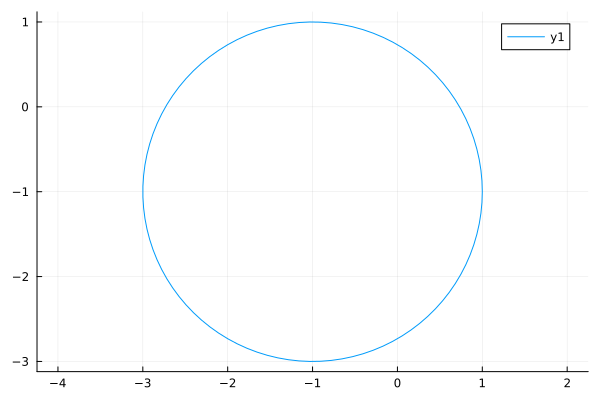

In [62]:
t = LinRange(0, 2*pi, 100)
x = 2*cos.(t) .- 1
y = 2*sin.(t) .- 1
plot(x,y, ratio = 1)

In [ ]:
function distance_curves((p, pdot), (q, qdot))
    
    gradf(X) = begin
        t, u = X
        diff = p(t) - q(u)
        [
            2 * dot(pdot(t), diff),
           -2 * dot(qdot(u), diff)
        ]
    end

    res = gradmet(gradf, 0.01, rand(2))
    Xopt = res.X[end]   # zadnja iteracija
    t, u = Xopt

    P = Tuple(p(t))
    Q = Tuple(q(u))
    d = norm(p(t) - q(u))

    return (d = d, P = P, Q = Q)
end

distance_curves (generic function with 2 methods)

In [77]:
p(t) = [cos(t) + 2; sin(t)]
pdot(t) = [-sin(t); cos(t)]

q(t) = [cos(t) - 2; sin(t)]
qdot(t) = [-sin(t); cos(t)]
distance_curves((p, pdot), (q, qdot))

(d = 4.0, P = (1.0000000000000142, 1.6893708311183713e-7), Q = (-2.999999999999986, 1.6893708311183713e-7))